In [240]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

In [241]:
df=pd.read_csv("traintitanic.csv")
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
853,854,1,1,"Lines, Miss. Mary Conover",female,16.0,0,1,PC 17592,39.4000,D28,S
360,361,0,3,"Skoog, Mr. Wilhelm",male,40.0,1,4,347088,27.9000,NaN,S
283,284,1,3,"Dorking, Mr. Edward Arthur",male,19.0,0,0,A/5. 10482,8.0500,NaN,S
622,623,1,3,"Nakid, Mr. Sahid",male,20.0,1,1,2653,15.7417,NaN,C
842,843,1,1,"Serepeca, Miss. Augusta",female,30.0,0,0,113798,31.0000,NaN,C


<Axes: >

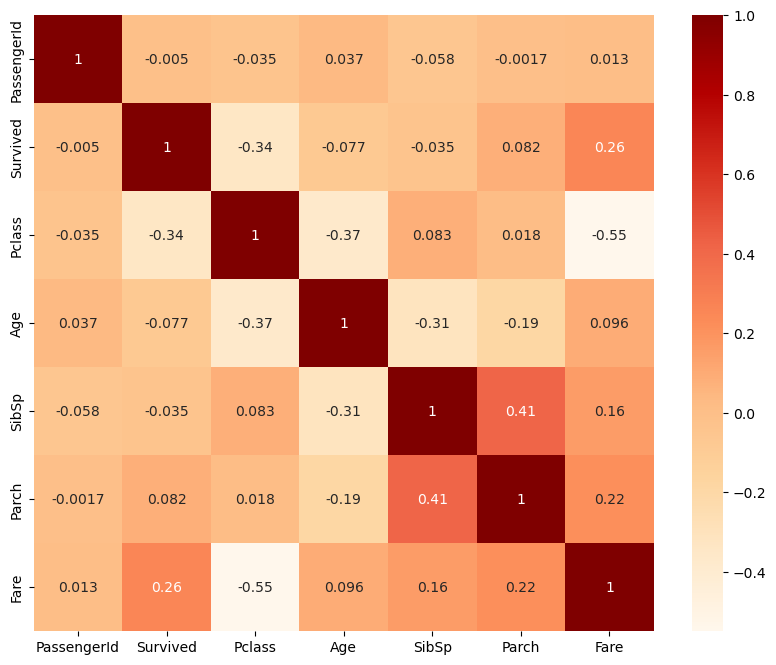

In [242]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(),cmap='OrRd',annot=True)

In [243]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0]
missing_df = pd.DataFrame({
    'Missing_Percentage': missing_percentage,
    'Dtype': df[missing_percentage.index].dtypes
})
print(missing_df.sort_values(by='Missing_Percentage', ascending=False))

          Missing_Percentage    Dtype
Cabin              77.104377   object
Age                19.865320  float64
Embarked            0.224467   object


In [244]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>],
       [<Axes: title={'center': 'Parch'}>,
        <Axes: title={'center': 'Fare'}>]], dtype=object)

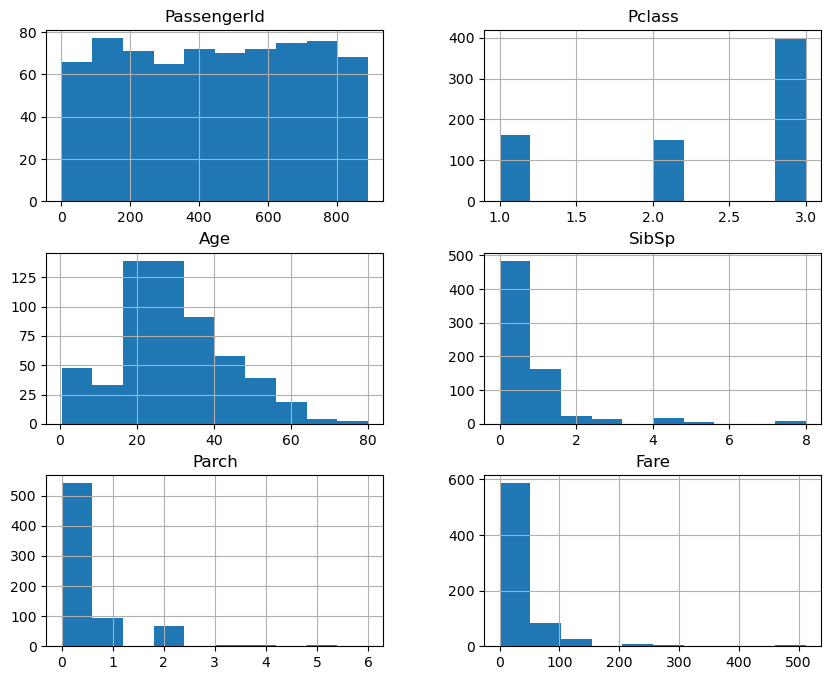

In [245]:
x_train.hist(figsize=(10,8))

In [246]:
x=df.drop(['Survived'],axis=1)
y=df['Survived']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

LOG 

In [247]:
cols5=['Age','SibSp','Parch','Fare']
class LogTransformer(BaseEstimator, TransformerMixin):
    def fit(self, x, y=None):
        return self
    def transform(self, x):
        x = x.copy()
        x[cols5] = np.log1p(x[cols5])
        return x

FEATURE DROPPER

In [248]:
cols1=['PassengerId','Name','Cabin','Ticket']
class drop(BaseEstimator,TransformerMixin):
    def fit(self,x,y=None):
        return self
    def transform(self,x):
        x=x.drop(cols1,axis=1)
        return x

NUM IMPUTER

In [249]:
x_train[['Sex', 'Embarked']]

,Sex,Embarked
331,male,S
733,male,S
382,male,S
704,male,S
813,female,S
...,...,...
106,female,S
270,male,S
860,male,S
435,female,S


In [250]:
cols2=['Fare','Age']
class impute(BaseEstimator,TransformerMixin):
    def fit(self,x,y=None):
        return self
    def transform(self,x):
        si=SimpleImputer(strategy="mean")
        x[cols2]=si.fit_transform(x[cols2])
        return x

In [251]:
cols4=['Embarked']
class catimpute(BaseEstimator,TransformerMixin):
    def fit(self,x,y=None):
        return self
    def transform(self,x):
        ci=SimpleImputer(strategy="most_frequent")
        x[cols4]=ci.fit_transform(x[cols4])
        return x

ONE HOT ENCODER

In [252]:
cols3 = ['Sex', 'Embarked']

class cat(BaseEstimator, TransformerMixin):
    def fit(self, x, y=None):
        self.ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        self.ohe.fit(x[cols3])
        return self
    def transform(self, x):
        enc = self.ohe.transform(x[cols3])
        enc = pd.DataFrame(
            enc,
            columns=self.ohe.get_feature_names_out(cols3),
            index=x.index
        )
        x = x.drop(columns=cols3)
        x = pd.concat([x, enc], axis=1)
        return x

In [258]:
pipe=Pipeline([
    ('drop_cols',drop()),
    ('num_impute',impute()),
    ('cat_impute',catimpute()),
    ('ohe',cat()),
    ('scaler', StandardScaler()),
    ('Model',LogisticRegression())
])

In [259]:
x = drop().fit_transform(x_train)
print("drop ok", x.shape)

x = impute().fit_transform(x)
print("num impute ok", x.shape)

x = catimpute().fit_transform(x)
print("cat impute ok", x.shape)

x = cat().fit_transform(x)
print("ohe ok", x.shape)

x = logtrans().fit_transform(x)
print("log ok", x.shape)

print(x.dtypes)

drop ok (712, 7)
num impute ok (712, 7)
cat impute ok (712, 7)
ohe ok (712, 10)
log ok (712, 10)
Pclass          int64
Age           float64
SibSp         float64
Parch         float64
Fare          float64
Sex_female    float64
Sex_male      float64
Embarked_C    float64
Embarked_Q    float64
Embarked_S    float64
dtype: object


In [260]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('drop_cols', drop()), ('num_impute', impute()),
                ('cat_impute', catimpute()), ('ohe', cat()),
                ('scaler', StandardScaler()), ('Model', LogisticRegression())])

In [261]:
y_pred=pipe.predict(x_test)

In [262]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8100558659217877
[[90 15]
 [19 55]]


In [263]:
df2=pd.read_csv("testtitanic.csv")
y_res=pipe.predict(df2)

In [267]:
submission = pd.DataFrame({
    'PassengerId': range(892, 892 + len(y_res)),
    'Survived': y_res
})

submission.to_csv('titanicsub.csv', index=False)